### Load in Protein Data

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values
adata.obsm["X_umap"] = umap.values

C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\evanj\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
C:\Users\evanj\anaconda3\Lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning

### Functions:
1. Find Neighbooring Cell Matrix
2. Find Overall Cell Matrix

In [4]:
def create_neighborhood_matrix(adata,pmn_threshold,spatial_method,radius=15):

    import my_functions
    import pandas as pd
    
    # Initialize collection DataFrames
    all_total_counts_R = pd.DataFrame()
    all_total_counts_NR = pd.DataFrame()
    all_total_counts_R_percent = pd.DataFrame()
    all_total_counts_NR_percent = pd.DataFrame()
    
    # mininum number of pmn cells
    pmn_floor=pmn_threshold
    radius=radius # Radius in microns
    sample_count=0 # Number of samples meeting threshold requirements
    
    for i in range(1, 4):
        for j in range(1, 26):
            sample_id = f"c_{i}_{j}_"
            pmn_count = my_functions.pmn_counter(adata, sample_id)["PMN decimal"]
            if pmn_count <= pmn_floor:
                continue

            # If passes the PMN threshold update the sample count
            sample_count+=1
            
            # Get results from your function
            results = my_functions.average_cell_counts(adata, i, j, "radius", radius)
            total_counts = results["Total Cell Counts"]
    
            # Extract total cell count value (from the "Total Cell Count" column)
            total_cell_count = total_counts["Total Cell Count"].values[0]
    
            # Drop that column before calculating percentages
            counts_no_total = total_counts.drop(columns=["Total Cell Count"])
    
            # Calculate percentages of each cell type
            percent_row = (counts_no_total / total_cell_count) * 100
    
            # Append to appropriate response group
            response = my_functions.get_sample_info(adata, sample_id)["Response"]
            if response == "R":
                all_total_counts_R = pd.concat([all_total_counts_R, total_counts])
                all_total_counts_R_percent = pd.concat([all_total_counts_R_percent, percent_row])
            elif response == "NR":
                all_total_counts_NR = pd.concat([all_total_counts_NR, total_counts])
                all_total_counts_NR_percent = pd.concat([all_total_counts_NR_percent, percent_row])

            # Replace NaNs with 0 for safety
            all_total_counts_R.fillna(0, inplace=True)
            all_total_counts_NR.fillna(0, inplace=True)
            all_total_counts_R_percent.fillna(0, inplace=True)
            all_total_counts_NR_percent.fillna(0, inplace=True)

    return{
        "Responder Percentile Matrix":all_total_counts_R_percent,
        "Non-Responder Percentile Matrix":all_total_counts_NR_percent,
        "Number of Samples": sample_count
    }

def get_cell_type_percentages(adata,pmn_threshold):

    import my_functions
    import pandas as pd


    #initialize output
    output_percent_R=pd.DataFrame()
    output_percent_NR=pd.DataFrame()
    output_percent=pd.DataFrame()
    pmn_floor=pmn_threshold

    # Iterate through 
    for i in range(1,4):
        for j in range(1,26):

            #Set sample Id in format
            sample_id=f"c_{i}_{j}_"
            pmn_count = my_functions.pmn_counter(adata, sample_id)["PMN decimal"]
            # Pmn floor is typically 25
            if pmn_count <= pmn_floor:
                continue
            percentages = my_functions.get_sample_cell_percentages(adata, sample_id)["Percentage Counts"]
            # Append the percentage row to the overall DataFram
            output_percent=pd.concat([output_percent,percentages])
            if my_functions.get_sample_info(adata,sample_id)["Response"]=="R":
                output_percent_R = pd.concat([output_percent_R, percentages])
            elif my_functions.get_sample_info(adata,sample_id)["Response"]=="NR":
                output_percent_NR = pd.concat([output_percent_NR, percentages])

    # Replaces Nans with 0 to pererve the numerical type of the matrix
    output_percent.fillna(0, inplace=True)
    output_percent_R.fillna(0, inplace=True)
    output_percent_NR.fillna(0, inplace=True)
    
    # Reorder Columns Alphabetically
    output_percent = output_percent[sorted(output_percent.columns)]
    output_percent_R = output_percent_R[sorted(output_percent_R.columns)]
    output_percent_NR = output_percent_NR[sorted(output_percent_NR.columns)]
    
    return{
        "All Percentage": output_percent,
        "R Percentage": output_percent_R,
        "NR Percentage": output_percent_NR
    }
import matplotlib.pyplot as plt

def plot_cell_type_pie_charts(percentages_dict):
    """
    Creates pie charts showing overall cell type frequencies 
    for responders and nonresponders.
    """
    # Sum percentages across all samples
    R_sum = percentages_dict["R Percentage"].sum()
    NR_sum = percentages_dict["NR Percentage"].sum()

    # Drop cell types with total frequency of 0
    R_sum = R_sum[R_sum > 0]
    NR_sum = NR_sum[NR_sum > 0]

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].pie(R_sum, labels=R_sum.index, autopct='%1.1f%%', startangle=140)
    axes[0].set_title('Responder Cell Type Composition')

    axes[1].pie(NR_sum, labels=NR_sum.index, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('Nonresponder Cell Type Composition')

    plt.tight_layout()
    plt.show()


### Display overall percentages pie chart

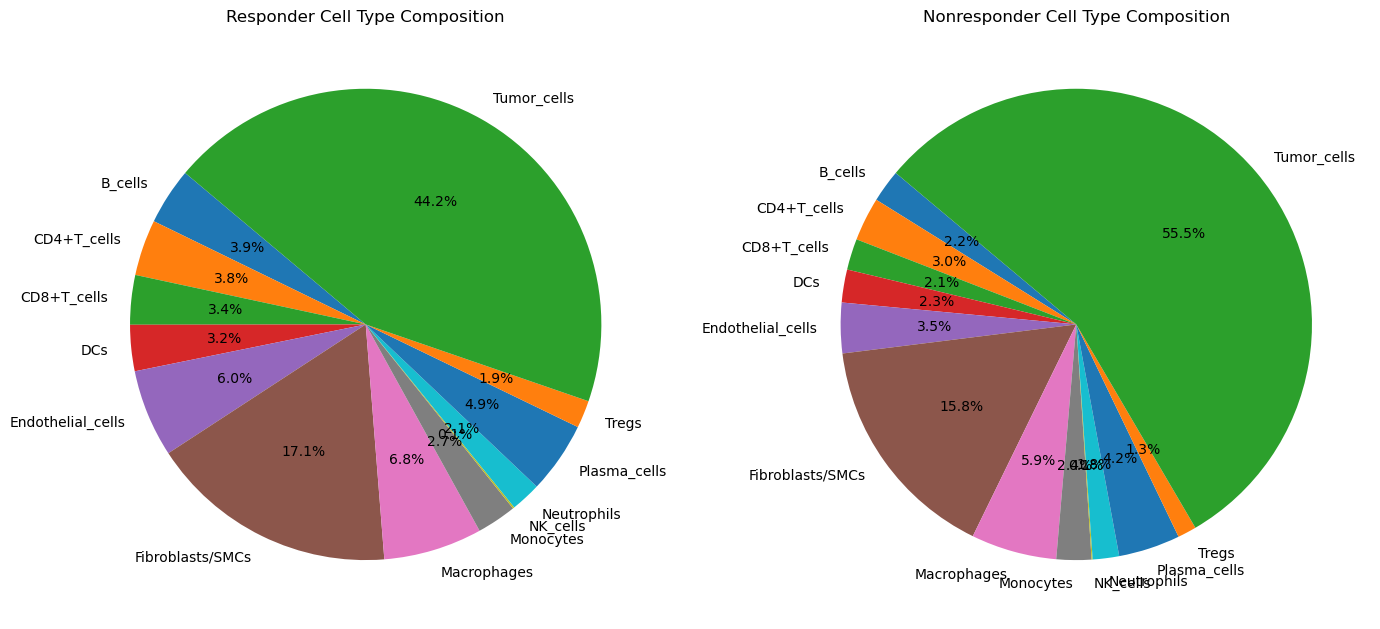

In [8]:
import matplotlib.pyplot as plt

def plot_cell_type_pie_charts(percentages_dict):
    """
    Creates pie charts showing overall cell type frequencies 
    for responders and nonresponders.
    """
    # Sum percentages across all samples
    R_sum = percentages_dict["R Percentage"].sum()
    NR_sum = percentages_dict["NR Percentage"].sum()

    # Drop cell types with total frequency of 0
    R_sum = R_sum[R_sum > 0]
    NR_sum = NR_sum[NR_sum > 0]

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
    axes[0].pie(R_sum, labels=R_sum.index, autopct='%1.1f%%', startangle=140)
    axes[0].set_title('Responder Cell Type Composition')

    axes[1].pie(NR_sum, labels=NR_sum.index, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('Nonresponder Cell Type Composition')

    plt.tight_layout()
    plt.show()
    
results = get_cell_type_percentages(adata, pmn_threshold=0.001)
plot_cell_type_pie_charts(results)


### Detla Matrix Creation

In [6]:
import my_functions
import pandas as pd

pmn_threshold=0.03
radius_um=15

# Call Functions
overall_cell_types=get_cell_type_percentages(adata,pmn_threshold)
neighborhood_matrix=create_neighborhood_matrix(adata,pmn_threshold,"delaunay",radius_um)

# Assign Variables
overall_cell_types_R=overall_cell_types["R Percentage"]
overall_cell_types_NR=overall_cell_types["NR Percentage"]
neighborhood_matrix_R=neighborhood_matrix["Responder Percentile Matrix"]
neighborhood_matrix_NR=neighborhood_matrix["Non-Responder Percentile Matrix"]
print(f"At a PMN threshold of {pmn_threshold*100} there are {neighborhood_matrix["Number of Samples"]} samples")

display(overall_cell_types_R)
display(neighborhood_matrix_R)

# Standardize Matrix
neighborhood_matrix_R.index.name = 'Sample ID'
overall_cell_types_R.index.name = 'Sample ID'
neighborhood_matrix_NR.index.name = 'Sample ID'
overall_cell_types_NR.index.name = 'Sample ID'

overall_cell_types_R.index = overall_cell_types_R.index.str.rstrip('_')
overall_cell_types_NR.index = overall_cell_types_NR.index.str.rstrip('_')

# Create a diff matrix
diff_responder=neighborhood_matrix_R-overall_cell_types_R
diff_non_responder=neighborhood_matrix_NR-overall_cell_types_NR

# Calculate the average across rows (column-wise mean)
average_row_r = pd.DataFrame([diff_responder.mean()], index=["Average"])
average_row_nr = pd.DataFrame([diff_non_responder.mean()], index=["Average"])


# Append it to the original DataFrame
diff_responder_with_avg = pd.concat([diff_responder, average_row_r])
diff_non_responder_with_avg = pd.concat([diff_non_responder, average_row_nr])

# Combine responder and non-responder groups
delta_neighborhood_percent_R = diff_responder_with_avg.copy()
delta_neighborhood_percent_NR = diff_non_responder_with_avg.copy()

# Preserve index as 'sample' for identification
delta_neighborhood_percent_R['sample'] = delta_neighborhood_percent_R.index
delta_neighborhood_percent_NR['sample'] = delta_neighborhood_percent_NR.index

delta_neighborhood_percent_R['response'] = 'R'
delta_neighborhood_percent_NR['response'] = 'NR'

delta_full_neighboor_matrix = pd.concat([delta_neighborhood_percent_R, delta_neighborhood_percent_NR])

At a PMN threshold of 3.0 there are 12 samples


merged_annot_cluster,B_cells,CD4+T_cells,CD8+T_cells,DCs,Endothelial_cells,Fibroblasts/SMCs,Macrophages,Monocytes,NK_cells,Neutrophils,Plasma_cells,Tregs,Tumor_cells
c_1_11_,3.732609,6.786563,5.632847,4.343400,0.000000,13.776722,20.732949,8.245674,0.033933,4.004072,7.804547,2.782491,22.124194
c_1_20_,0.729614,2.703863,0.557940,2.188841,1.459227,54.334764,3.519313,2.403433,0.257511,3.433476,6.523605,1.030043,20.858369
c_1_21_,1.838509,5.366460,7.055901,5.987578,0.000000,5.913043,20.298137,6.360248,0.198758,12.298137,5.515528,2.161491,27.006211
c_1_24_,1.220044,4.008715,0.784314,4.880174,0.000000,9.281046,5.838780,2.570806,0.087146,6.405229,0.740741,2.396514,61.786492
c_2_13_,4.159812,8.766157,4.958872,10.411281,0.070505,16.098707,15.323149,7.191539,0.423032,7.873090,5.358402,2.867215,16.498237
c_3_7_,0.378347,0.349243,0.494761,0.727590,0.000000,16.298021,5.034924,2.793946,0.058207,3.696158,2.968568,0.116414,67.083818


,Neutrophils,Monocytes,Tumor_cells,Macrophages,Fibroblasts/SMCs,CD4+T_cells,Plasma_cells,DCs,CD8+T_cells,B_cells,Tregs,NK_cells,Endothelial_cells
Sample ID,,,,,,,,,,,,,
c_1_11,14.646465,11.363636,25.505051,14.646465,13.131313,3.787879,4.797980,5.303030,2.777778,3.030303,1.010101,0.000000,0.000000
c_1_20,27.053140,3.381643,43.478261,3.864734,13.043478,2.415459,3.864734,1.932367,0.000000,0.000000,0.000000,0.483092,0.483092
c_1_21,47.941399,5.430664,9.396312,9.876231,3.738318,2.475373,3.738318,8.385956,6.339985,1.439758,1.035615,0.202071,0.000000
c_1_24,62.713797,0.798176,15.621437,2.736602,3.648803,1.824401,0.114025,11.516534,0.228050,0.570125,0.228050,0.000000,0.000000
c_2_13,16.023739,7.333616,4.154303,18.694362,9.707503,9.368376,7.630352,14.455278,5.765155,4.111912,2.246715,0.508690,0.000000
c_3_7,18.057922,5.281090,30.834753,13.117547,21.294719,0.681431,6.984668,3.236797,0.340716,0.000000,0.170358,0.000000,0.000000


### Get P Values

In [7]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu

input_matrix = delta_full_neighboor_matrix.copy()

# Separate responder and non-responder groups
responder_matrix = input_matrix[input_matrix['response'] == 'R']
non_responder_matrix = input_matrix[input_matrix['response'] == 'NR']

# List of columns to test (excluding 'response' column)
cell_type_columns = [col for col in input_matrix.columns if col not in ['sample', 'response']]

# Store results
results = []

for cell_type in cell_type_columns:
    r_data = responder_matrix[cell_type]
    nr_data = non_responder_matrix[cell_type]

    # Two-tailed t-test
    t_stat, p_ttest = ttest_ind(r_data, nr_data, equal_var=False)

    # Mann-Whitney U test (Wilcoxon rank-sum test for independent samples)
    u_stat, p_wilcoxon = mannwhitneyu(r_data, nr_data, alternative='two-sided')

    results.append({
        'cell_type': cell_type,
        't_statistic': t_stat,
        't_p_value': p_ttest,
        'u_statistic': u_stat,
        'wilcoxon_p_value': p_wilcoxon
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
display(results_df)



,cell_type,t_statistic,t_p_value,u_statistic,wilcoxon_p_value
0,B_cells,-2.236596,0.047435,9.0,0.053030
1,CD4+T_cells,-1.907474,0.080682,14.0,0.208625
2,CD8+T_cells,-2.095359,0.060693,5.0,0.011072
3,DCs,-0.885606,0.393571,18.0,0.455711
4,Endothelial_cells,NaN,NaN,NaN,NaN
5,Fibroblasts/SMCs,-0.540905,0.599545,18.0,0.455711
6,Macrophages,-0.959916,0.356722,18.0,0.455711
7,Monocytes,-2.760156,0.021003,6.0,0.017483
8,NK_cells,1.615603,0.140091,35.0,0.200841
9,Neutrophils,-0.246753,0.811056,19.0,0.534965


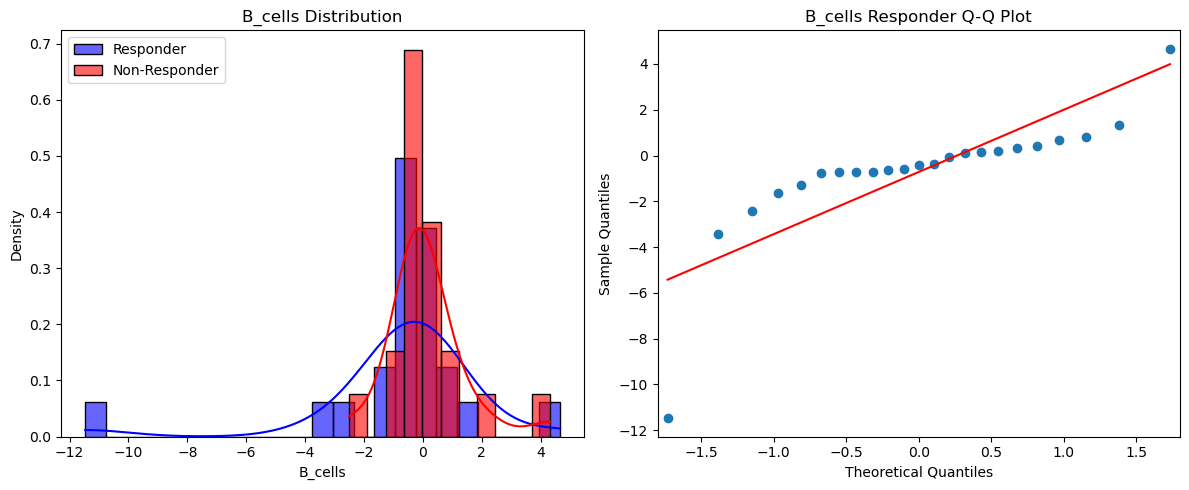

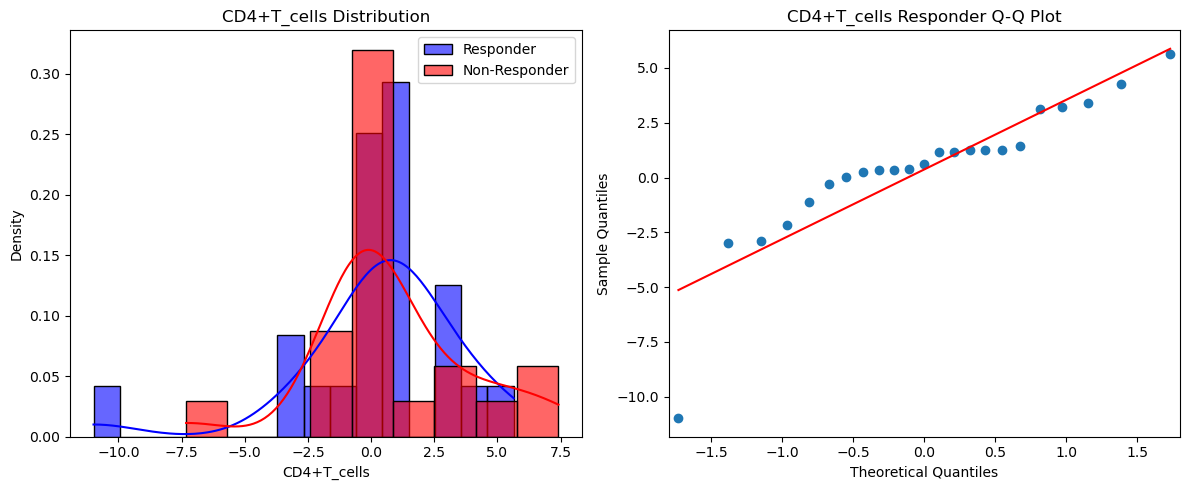

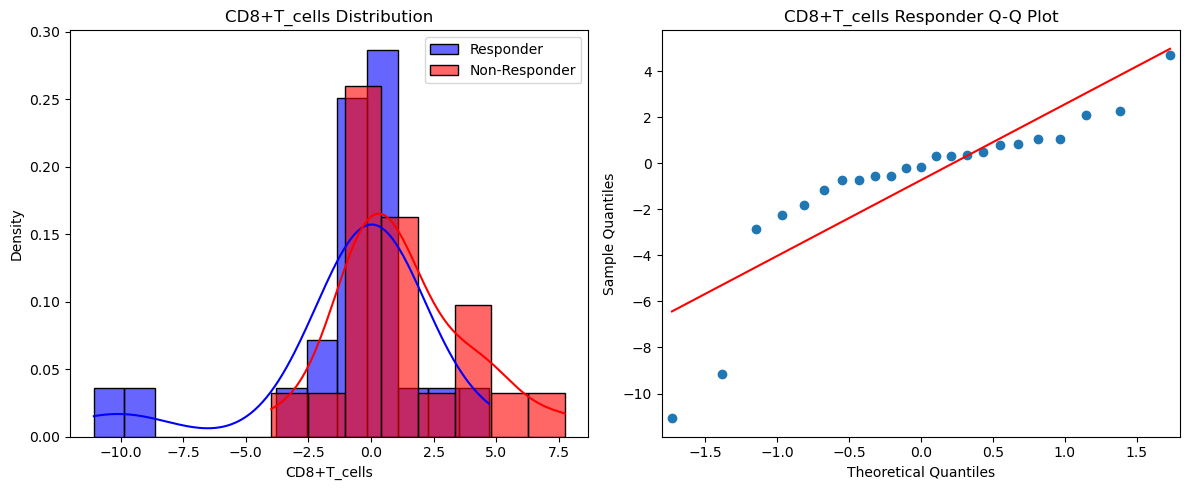

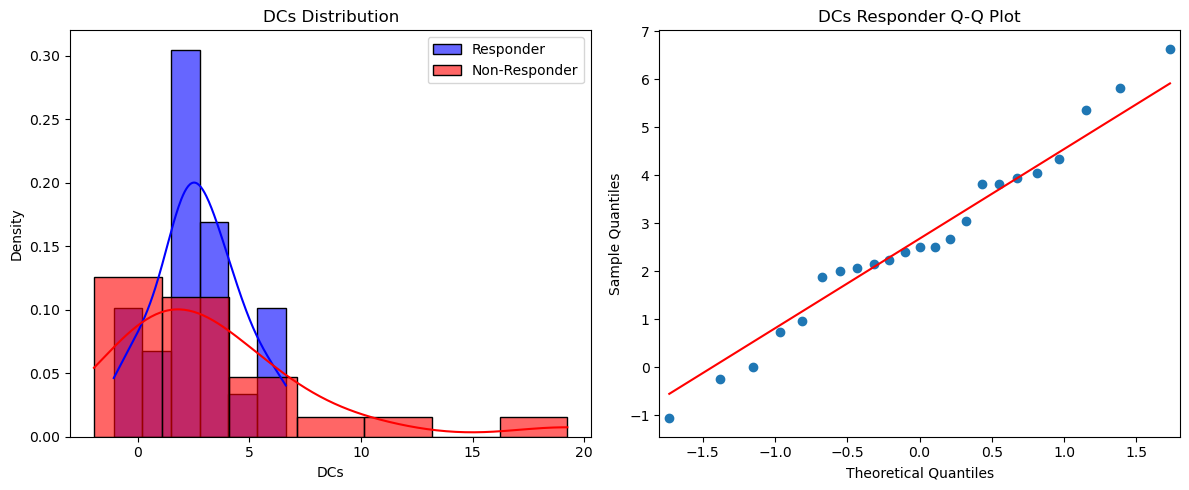

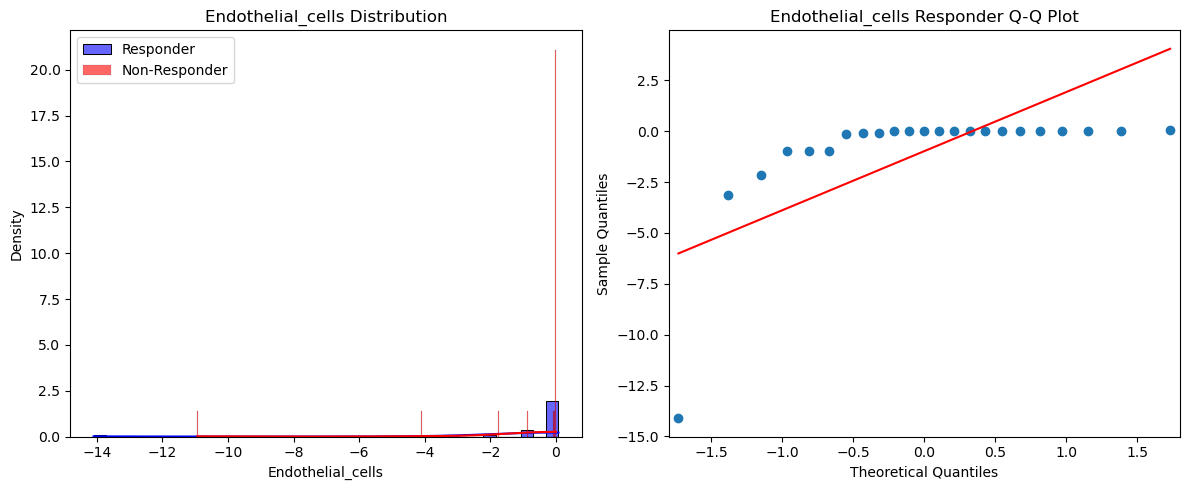

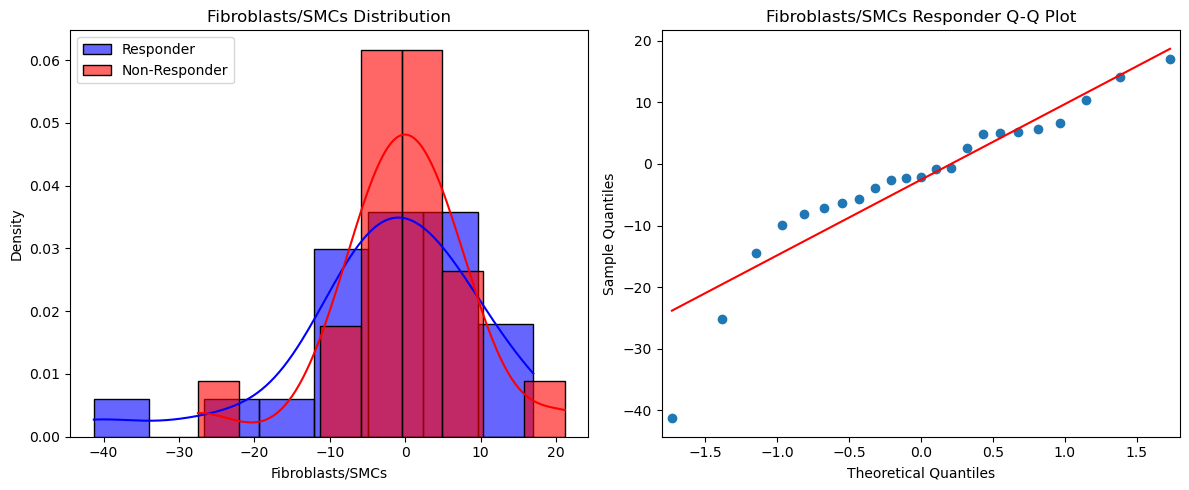

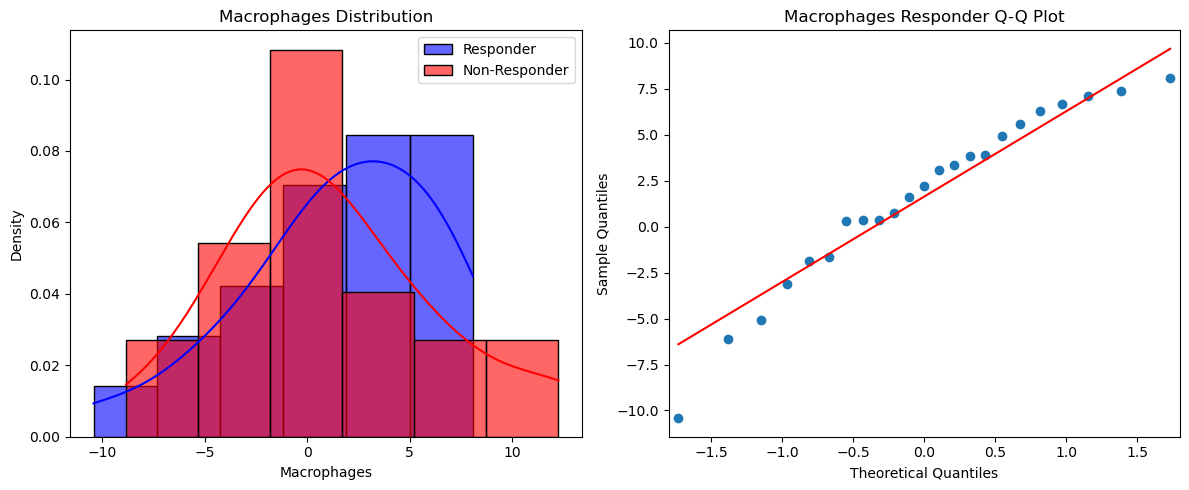

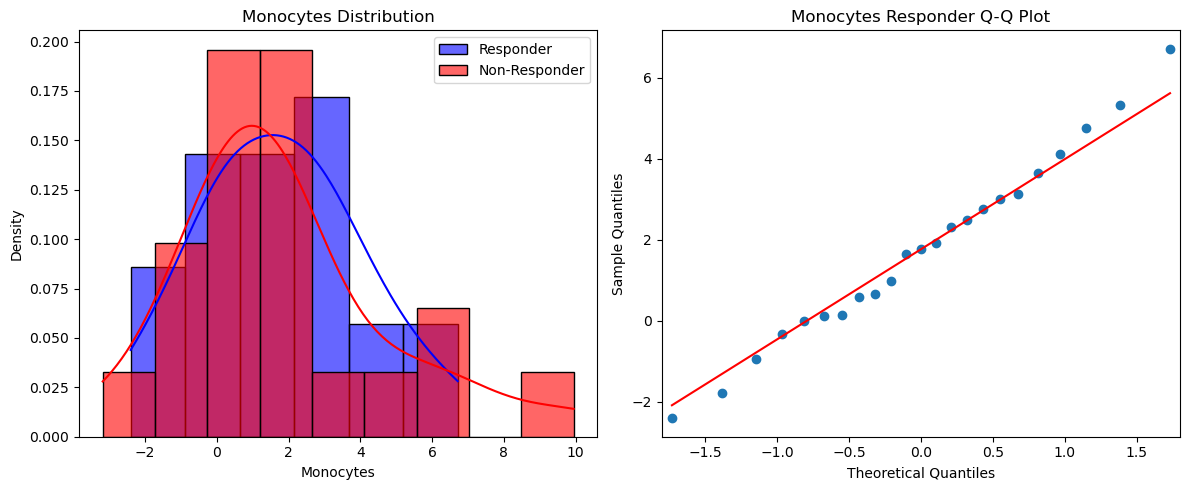

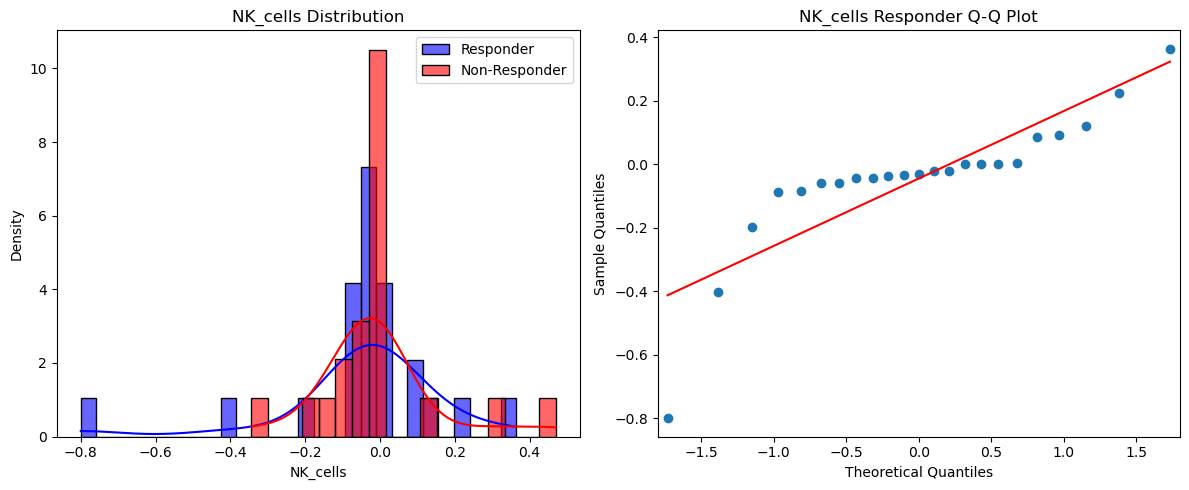

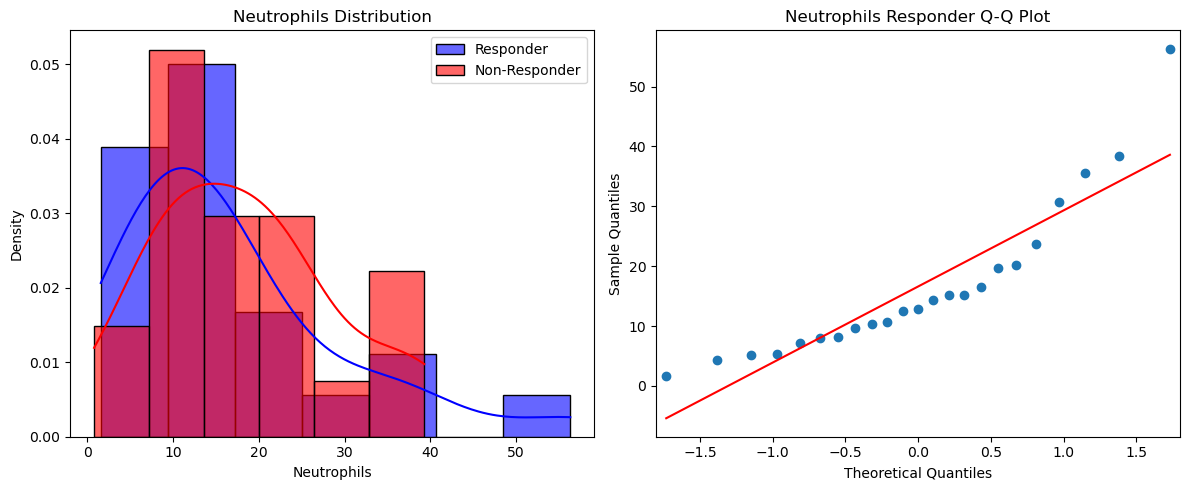

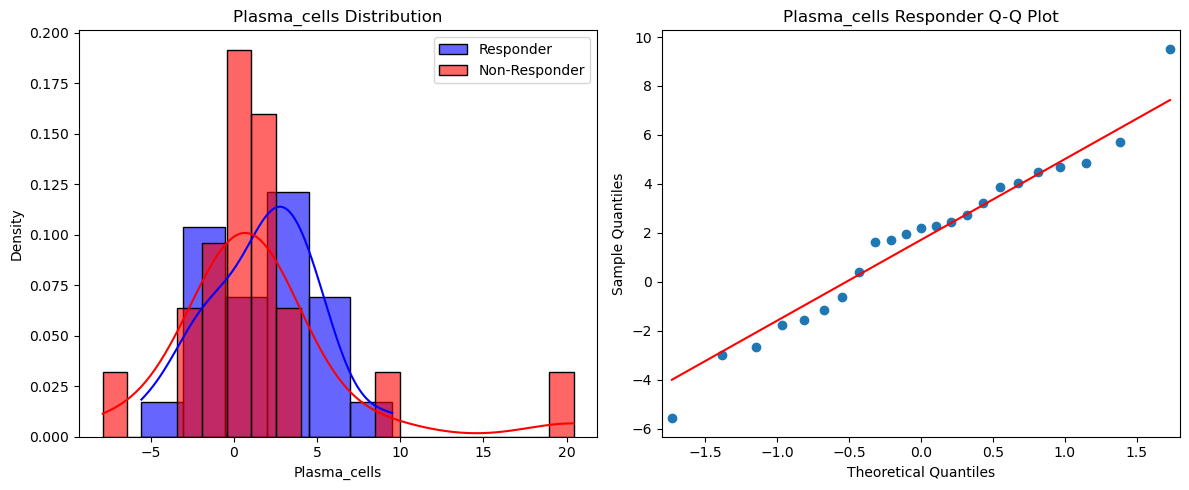

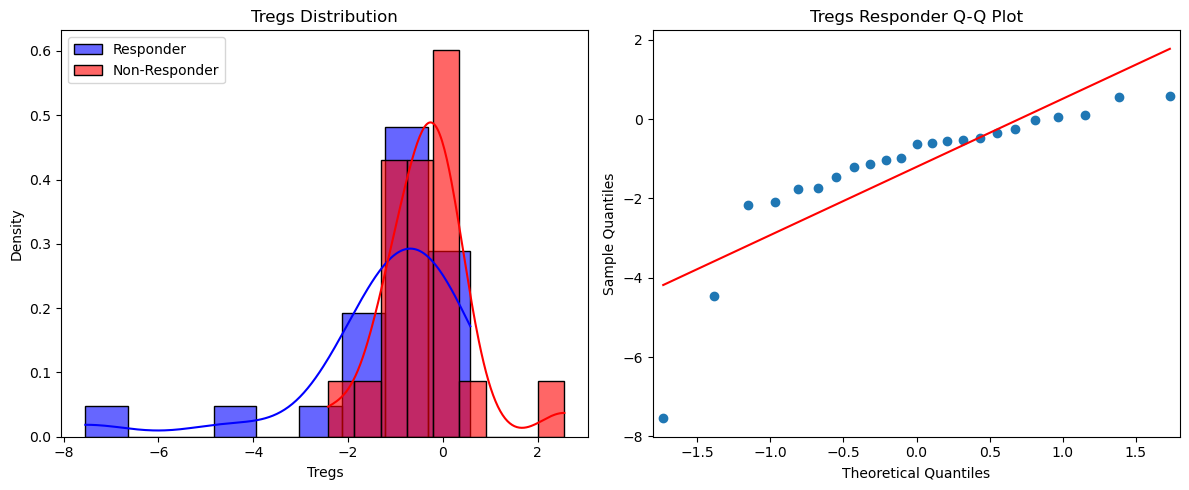

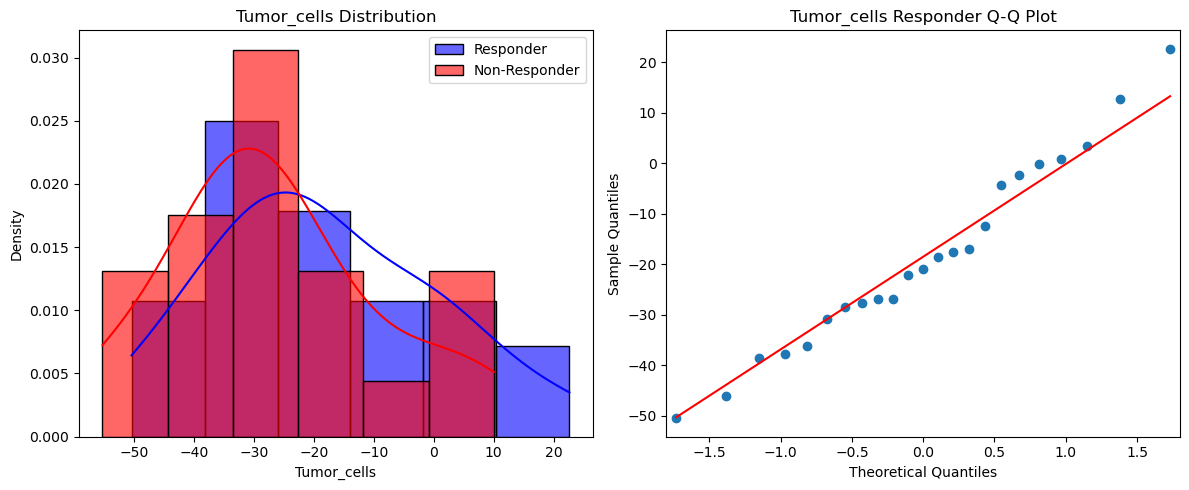

In [18]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, shapiro
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

input_matrix = delta_full_neighboor_matrix.copy()

# Separate responder and non-responder groups
responder_matrix = input_matrix[input_matrix['response'] == 'R']
non_responder_matrix = input_matrix[input_matrix['response'] == 'NR']

# List of columns to test (excluding 'response' column)
cell_type_columns = [col for col in input_matrix.columns if col not in ['sample', 'response']]

# Store results
results = []

for cell_type in cell_type_columns:
    r_data = responder_matrix[cell_type].dropna()
    nr_data = non_responder_matrix[cell_type].dropna()

    # Two-tailed t-test
    t_stat, p_ttest = ttest_ind(r_data, nr_data, equal_var=False)

    # Mann-Whitney U test
    u_stat, p_wilcoxon = mannwhitneyu(r_data, nr_data, alternative='two-sided')

    results.append({
        'cell_type': cell_type,
        't_statistic': t_stat,
        't_p_value': p_ttest,
        'u_statistic': u_stat,
        'wilcoxon_p_value': p_wilcoxon
    })

    # Plot distribution
    plt.figure(figsize=(12, 5))
    
    # Histogram + KDE
    plt.subplot(1, 2, 1)
    sns.histplot(r_data, kde=True, color='blue', label='Responder', stat='density', alpha=0.6)
    sns.histplot(nr_data, kde=True, color='red', label='Non-Responder', stat='density', alpha=0.6)
    plt.title(f'{cell_type} Distribution')
    plt.xlabel(cell_type)
    plt.ylabel('Density')
    plt.legend()

    # Q-Q Plots
    plt.subplot(1, 2, 2)
    sm.qqplot(r_data, line='s', ax=plt.gca())
    plt.title(f'{cell_type} Responder Q-Q Plot')

    plt.tight_layout()
    plt.show()

    # Optional: Add Shapiro-Wilk test
